# 18-2 · Análisis Discriminante (*Discriminant Analysis*)

Seguimos con el mismo amigo impredecible. Ahora tenemos **dos predictores numéricos**:

- `temperatura` — temperatura del día (°C)
- `hora_invitacion` — hora a la que lo invitamos (10–21h)

**Naive Bayes** miraba cada predictor por separado. **LDA** (Linear Discriminant Analysis) hace algo distinto: busca la **dirección** en el espacio 2D que mejor separa las clases, considerando cómo los predictores **covarían** juntos.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder

df = pd.read_csv("../data/friends.csv")
PREDICTORS = ["temperatura", "hora_invitacion"]
TARGET = "sale"
CLASSES = ["No", "Sí"]  # No=0, Sí=1

enc_y = OrdinalEncoder(categories=[CLASSES])
df["sale_num"] = enc_y.fit_transform(df[[TARGET]]).ravel().astype(int)

print(df[PREDICTORS + [TARGET]].head(10))
print(f"\nShape: {df.shape}")
print(f"\n¿Sale? →\n{df[TARGET].value_counts()}")

   temperatura  hora_invitacion sale
0         21.7             20.0   No
1         18.9             18.8   No
2         26.6             15.6   Sí
3         30.1             17.8   Sí
4         23.1             13.4   Sí
5         23.1             13.4   Sí
6         15.7             17.6   No
7         23.3             20.6   No
8         22.1             12.8   Sí
9         26.2             15.4   Sí

Shape: (40, 7)

¿Sale? →
sale
No    20
Sí    20
Name: count, dtype: int64


## 1 · Exploración: ¿Dónde caen los puntos?

Antes de modelar, veamos cómo se distribuyen los datos en el espacio 2D.

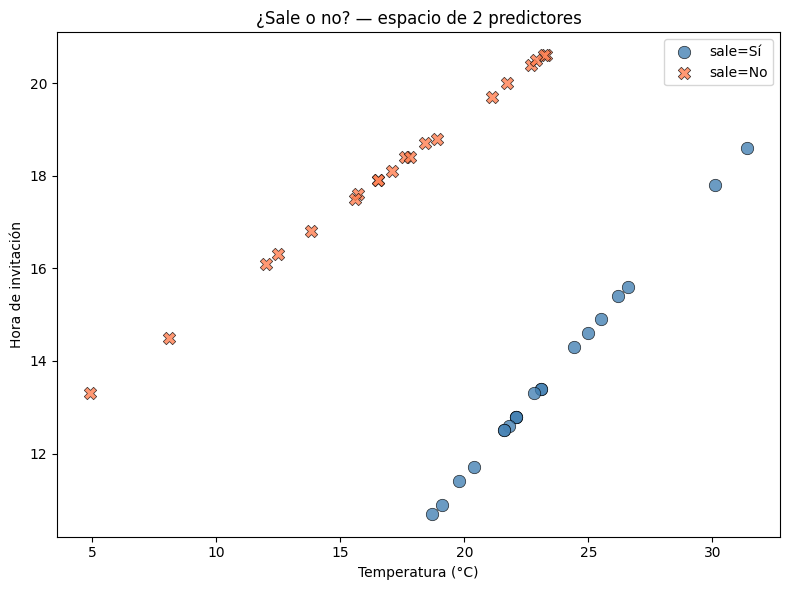

→ Los que SÍ salen: temperatura alta + invitación temprana
→ Los que NO salen: temperatura baja + invitación tardía


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for clase, color, marker in [("Sí", "steelblue", "o"), ("No", "coral", "X")]:
    mask = df[TARGET] == clase
    ax.scatter(
        df.loc[mask, "temperatura"],
        df.loc[mask, "hora_invitacion"],
        c=color,
        marker=marker,
        s=80,
        edgecolors="k",
        linewidths=0.5,
        label=f"sale={clase}",
        alpha=0.8,
    )

ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Hora de invitación")
ax.set_title("¿Sale o no? — espacio de 2 predictores")
ax.legend()
plt.tight_layout()
plt.show()

print("→ Los que SÍ salen: temperatura alta + invitación temprana")
print("→ Los que NO salen: temperatura baja + invitación tardía")

## 2 · ¿Qué es Covarianza? (*Covariance*)

La **covarianza** mide cómo dos variables se mueven juntas:

- **Positiva**: cuando una sube, la otra también
- **Negativa**: cuando una sube, la otra baja
- **~0**: no se mueven juntas

$$\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

La **matriz de covarianza** resume estas relaciones para todos los pares de variables. LDA usa esta matriz para entender la "forma" de cada nube de puntos.

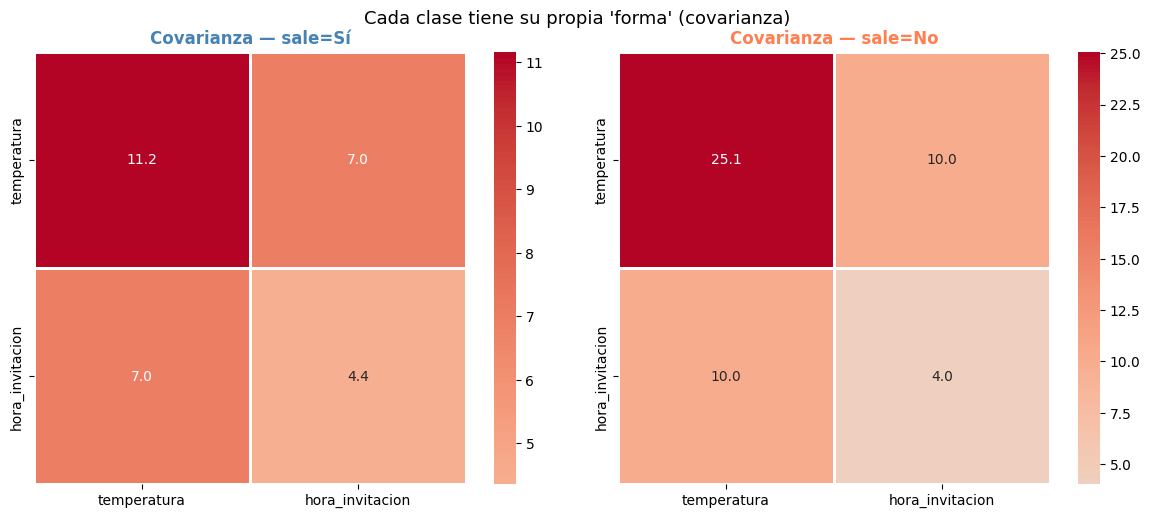

Covarianza pooled (compartida por ambas clases):
                 temperatura  hora_invitacion
temperatura            18.11             8.50
hora_invitacion         8.50             4.19


In [13]:
# Matriz de covarianza por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, clase, color in zip(axes, ["Sí", "No"], ["steelblue", "coral"]):
    sub = df.loc[df[TARGET] == clase, PREDICTORS]
    cov = sub.cov()
    sns.heatmap(
        cov,
        annot=True,
        fmt=".1f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        square=True,
        linewidths=1,
    )
    ax.set_title(f"Covarianza — sale={clase}", color=color, fontweight="bold")

plt.suptitle("Cada clase tiene su propia 'forma' (covarianza)", fontsize=13)
plt.tight_layout()
plt.show()

# Covarianza pooled (promedio ponderado de ambas clases)
# LDA asume que ambas clases comparten la MISMA matriz de covarianza
cov_si = df.loc[df[TARGET] == "Sí", PREDICTORS].cov()
cov_no = df.loc[df[TARGET] == "No", PREDICTORS].cov()
n_si = (df[TARGET] == "Sí").sum()
n_no = (df[TARGET] == "No").sum()
cov_pooled = ((n_si - 1) * cov_si + (n_no - 1) * cov_no) / (n_si + n_no - 2)

print("Covarianza pooled (compartida por ambas clases):")
print(cov_pooled.round(2))

## 3 · La idea de LDA

LDA busca una **dirección** (un eje) en el espacio de predictores que:

1. **Maximiza** la distancia entre los centros (*means*) de las clases
2. **Minimiza** la dispersión (*spread*) dentro de cada clase

Es como proyectar una sombra: LDA busca el ángulo donde las sombras de los dos grupos se separan más.

### Función discriminante (*discriminant function*)

$$w = \Sigma_{\text{pooled}}^{-1} (\mu_{\text{Sí}} - \mu_{\text{No}})$$

Donde:
- $\Sigma_{\text{pooled}}$ es la covarianza compartida
- $\mu_{\text{Sí}}, \mu_{\text{No}}$ son los vectores de medias de cada clase
- $w$ es el vector de **pesos discriminantes** (*discriminant weights*)

In [18]:
# Cálculo manual del vector discriminante
mu_si = np.array(df.loc[df[TARGET] == "Sí", PREDICTORS].mean())
mu_no = np.array(df.loc[df[TARGET] == "No", PREDICTORS].mean())

# w = Σ_pooled⁻¹ * (μ_Sí - μ_No)
cov_inv = np.linalg.inv(cov_pooled.values)
w = cov_inv @ (mu_si - mu_no)

print(f"Media clase Sí:  temperatura={mu_si[0]:.1f}°C, hora={mu_si[1]:.1f}h")
print(f"Media clase No:  temperatura={mu_no[0]:.1f}°C, hora={mu_no[1]:.1f}h")
print(f"\nVector discriminante w: [{w[0]:.4f}, {w[1]:.4f}]")
print(f"\n→ w[temperatura]={w[0]:.4f}: temperatura ALTA empuja hacia 'Sí sale'")
print(f"→ w[hora]={w[1]:.4f}: hora TARDÍA empuja hacia 'No sale'")

Media clase Sí:  temperatura=23.4°C, hora=13.6h
Media clase No:  temperatura=17.0°C, hora=18.1h

Vector discriminante w: [18.4101, -38.4679]

→ w[temperatura]=18.4101: temperatura ALTA empuja hacia 'Sí sale'
→ w[hora]=-38.4679: hora TARDÍA empuja hacia 'No sale'


## 4 · LDA con sklearn

Verifiquemos nuestro cálculo manual con `LinearDiscriminantAnalysis` de sklearn.

In [20]:
X = df[PREDICTORS].to_numpy()
y = df["sale_num"].to_numpy()  # No=0, Sí=1

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

print("=== sklearn LDA ===")
print(f"Coeficientes: {lda.coef_[0].round(4)}")
print(f"Intercepto:   {lda.intercept_[0]:.4f}")
print(f"Clases:       {CLASSES}")

# Los coeficientes de sklearn son proporcionales a nuestro w manual
ratio = lda.coef_[0] / w
print(f"\nRatio sklearn/manual: {ratio.round(4)}")
print("→ Son proporcionales (misma dirección, diferente escala)")

=== sklearn LDA ===
Coeficientes: [ 18.4101 -38.4679]
Intercepto:   238.0203
Clases:       ['No', 'Sí']

Ratio sklearn/manual: [1. 1.]
→ Son proporcionales (misma dirección, diferente escala)


## 5 · Proyección: De 2D a 1D

LDA proyecta cada punto sobre el **eje discriminante**. En 1D, podemos ver qué tan bien se separan las clases.

$$\text{score}_i = w_1 \cdot \text{temperatura}_i + w_2 \cdot \text{hora}_i$$

Cada observación recibe un **score** (puntaje discriminante). Si el score es alto → predecimos "Sí sale". Si es bajo → "No sale".

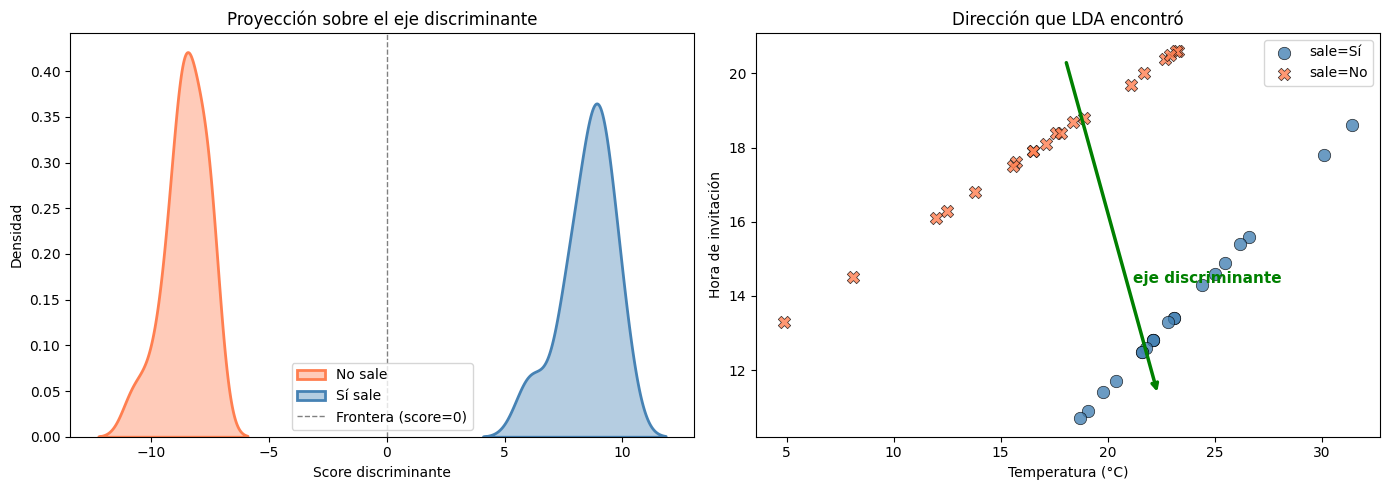

→ Izquierda: los scores 1D muestran buena separación entre clases
→ Derecha: la flecha verde es la dirección óptima de proyección


In [21]:
# Proyectar sobre el eje discriminante (transform da el score 1D)
scores = lda.transform(X).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Histograma de scores por clase
for clase, color, label in [(0, "coral", "No sale"), (1, "steelblue", "Sí sale")]:
    sns.kdeplot(
        scores[y == clase],
        ax=axes[0],
        color=color,
        fill=True,
        alpha=0.4,
        label=label,
        linewidth=2,
    )

axes[0].axvline(
    0, color="gray", linestyle="--", linewidth=1, label="Frontera (score=0)"
)
axes[0].set_xlabel("Score discriminante")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Proyección sobre el eje discriminante")
axes[0].legend()

# Panel 2: Scatter original con el eje discriminante superpuesto
for clase, color, marker in [("Sí", "steelblue", "o"), ("No", "coral", "X")]:
    mask = df[TARGET] == clase
    axes[1].scatter(
        df.loc[mask, "temperatura"],
        df.loc[mask, "hora_invitacion"],
        c=color,
        marker=marker,
        s=80,
        edgecolors="k",
        linewidths=0.5,
        label=f"sale={clase}",
        alpha=0.8,
    )

# Dibujar la dirección discriminante como flecha desde el centro
center = (mu_si + mu_no) / 2
arrow_len = 5
w_norm = w / np.linalg.norm(w)
axes[1].annotate(
    "",
    xy=center + arrow_len * w_norm,
    xytext=center - arrow_len * w_norm,
    arrowprops=dict(arrowstyle="->", color="green", lw=2.5),
)
axes[1].text(
    center[0] + 1,
    center[1] - 1.5,
    "eje discriminante",
    color="green",
    fontsize=11,
    fontweight="bold",
)

axes[1].set_xlabel("Temperatura (°C)")
axes[1].set_ylabel("Hora de invitación")
axes[1].set_title("Dirección que LDA encontró")
axes[1].legend()

plt.tight_layout()
plt.show()

print("→ Izquierda: los scores 1D muestran buena separación entre clases")
print("→ Derecha: la flecha verde es la dirección óptima de proyección")

## 6 · Frontera de Decisión (*Decision Boundary*)

La frontera es la línea en 2D donde LDA dice "50/50". A un lado predice "Sí sale", al otro "No sale".

$$w_1 \cdot \text{temperatura} + w_2 \cdot \text{hora} + b = 0$$

Es una **línea recta** (por eso se llama *Linear* Discriminant Analysis).

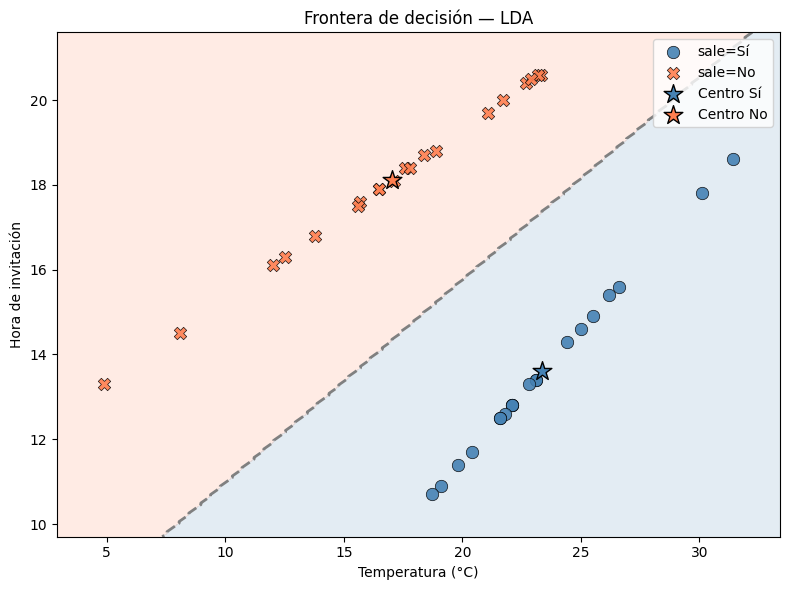

Accuracy en entrenamiento: 100.0%


In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

# Crear grid para colorear regiones
x_min, x_max = df["temperatura"].min() - 2, df["temperatura"].max() + 2
y_min, y_max = df["hora_invitacion"].min() - 1, df["hora_invitacion"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = lda.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Regiones coloreadas
ax.contourf(
    xx, yy, Z, alpha=0.15, levels=[-0.5, 0.5, 1.5], colors=["coral", "steelblue"]
)
ax.contour(xx, yy, Z, levels=[0.5], colors=["gray"], linewidths=2, linestyles="--")

# Puntos
for clase, color, marker in [("Sí", "steelblue", "o"), ("No", "coral", "X")]:
    mask = df[TARGET] == clase
    ax.scatter(
        df.loc[mask, "temperatura"],
        df.loc[mask, "hora_invitacion"],
        c=color,
        marker=marker,
        s=80,
        edgecolors="k",
        linewidths=0.5,
        label=f"sale={clase}",
        alpha=0.9,
    )

# Centros de cada clase
ax.scatter(
    *mu_si,
    c="steelblue",
    s=200,
    marker="*",
    edgecolors="k",
    zorder=5,
    label="Centro Sí",
)
ax.scatter(
    *mu_no, c="coral", s=200, marker="*", edgecolors="k", zorder=5, label="Centro No"
)

ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Hora de invitación")
ax.set_title("Frontera de decisión — LDA")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Accuracy
accuracy = lda.score(X, y)
print(f"Accuracy en entrenamiento: {accuracy:.1%}")

## 7 · Predicción: ¿Sale mi amigo?

Probemos con escenarios concretos. LDA nos da probabilidades, no solo "sí/no".

In [ ]:
escenarios = pd.DataFrame(
    {
        "temperatura": [25, 10, 20, 28],
        "hora_invitacion": [13, 20, 16, 19],
    }
)

probas = lda.predict_proba(escenarios.values)
pred_nums = lda.predict(escenarios.values)
preds = [CLASSES[int(p)] for p in pred_nums]

for i, row in escenarios.iterrows():
    print(
        f"Temp={row['temperatura']}°C, Hora={row['hora_invitacion']}h "
        f"→ P(Sí)={probas[i, 1]:.1%} → {preds[i]}"
    )

print("\n→ Día caliente + invitación temprana = alta probabilidad de que salga")
print("→ Día frío + invitación tardía = probablemente nos cancela")

Temp=25°C, Hora=13h → P(Sí)=100.0% → Sí
Temp=10°C, Hora=20h → P(Sí)=0.0% → No
Temp=20°C, Hora=16h → P(Sí)=0.0% → No
Temp=28°C, Hora=19h → P(Sí)=100.0% → Sí

→ Día caliente + invitación temprana = alta probabilidad de que salga
→ Día frío + invitación tardía = probablemente nos cancela


## 8 · LDA vs Naive Bayes (GaussianNB)

La diferencia clave:
- **GaussianNB**: trata cada predictor **por separado** (asume independencia)
- **LDA**: considera cómo los predictores **covarían juntos**

Comparemos sus fronteras de decisión.

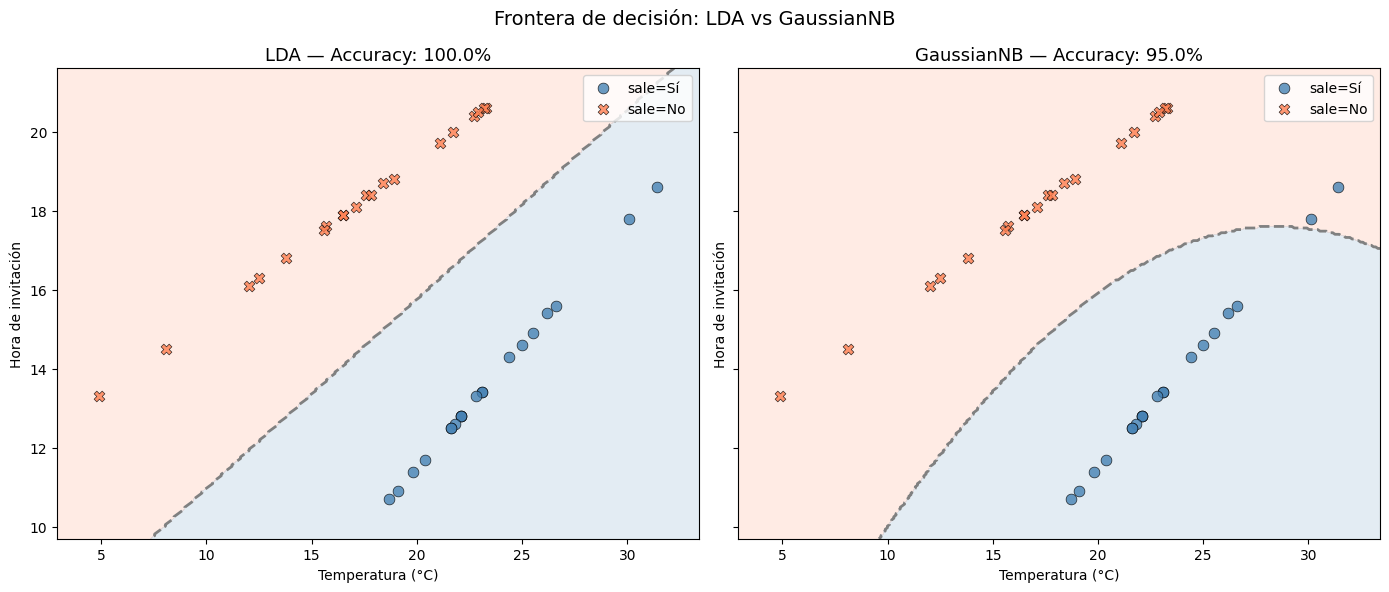

Accuracy LDA:        100.0%
Accuracy GaussianNB: 95.0%

→ LDA: frontera siempre recta (lineal)
→ GaussianNB: frontera puede ser curva (porque ignora covarianza)


In [9]:
gnb = GaussianNB()
gnb.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

models = [("LDA", lda), ("GaussianNB", gnb)]

for ax, (name, model) in zip(axes, models):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(
        xx, yy, Z, alpha=0.15, levels=[-0.5, 0.5, 1.5], colors=["coral", "steelblue"]
    )
    ax.contour(xx, yy, Z, levels=[0.5], colors=["gray"], linewidths=2, linestyles="--")

    for clase, color, marker in [("Sí", "steelblue", "o"), ("No", "coral", "X")]:
        mask = df[TARGET] == clase
        ax.scatter(
            df.loc[mask, "temperatura"],
            df.loc[mask, "hora_invitacion"],
            c=color,
            marker=marker,
            s=60,
            edgecolors="k",
            linewidths=0.5,
            label=f"sale={clase}",
            alpha=0.8,
        )

    acc = model.score(X, y)
    ax.set_title(f"{name} — Accuracy: {acc:.1%}", fontsize=13)
    ax.set_xlabel("Temperatura (°C)")
    ax.set_ylabel("Hora de invitación")
    ax.legend(loc="upper right")

plt.suptitle("Frontera de decisión: LDA vs GaussianNB", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Accuracy LDA:        {lda.score(X, y):.1%}")
print(f"Accuracy GaussianNB: {gnb.score(X, y):.1%}")
print("\n→ LDA: frontera siempre recta (lineal)")
print("→ GaussianNB: frontera puede ser curva (porque ignora covarianza)")

## 9 · Resumen

| Concepto | Descripción |
|----------|-------------|
| Covarianza (*covariance*) | Mide cómo dos variables se mueven juntas |
| Función discriminante (*discriminant function*) | La combinación lineal $w_1 x_1 + w_2 x_2 + b$ que mejor separa las clases |
| Pesos discriminantes (*discriminant weights*) | Los coeficientes $w$ — indican cuánto pesa cada predictor |
| Proyección (*projection*) | Reducir de 2D a 1D sobre el eje discriminante |
| Frontera de decisión | La línea (recta) donde P(Sí) = P(No) = 50% |

| LDA | GaussianNB |
|-----|------------|
| Considera covarianza entre predictores | Asume independencia entre predictores |
| Frontera siempre lineal (recta) | Frontera puede ser curva |
| Asume misma covarianza para ambas clases | Cada clase tiene su propia varianza |
| Robusto con pocos datos | Más flexible pero puede sobreajustar |

> 👈 LDA fue el primer clasificador estadístico (Fisher, 1936). Hoy es menos popular que logistic regression o tree models, pero sigue siendo útil como baseline y tiene conexiones con PCA (Principal Components Analysis).